# Case Study-

In [62]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import math
import seaborn as sns

In [94]:
artikel = pd.read_csv("data/case_data_artikelstammdaten.csv")
bestellungen = pd.read_csv("data/case_data_bestellungen.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/case_data_artikelstammdaten.csv'

In [64]:
artikel

,Artikelnummer,Bezeichnung,Länge,Breite,Höhe,Gewicht
0,ART00000,Artikel 0,850.0,300.0,195.0,5.017015
1,ART00001,Artikel 1,850.0,362.0,473.0,22.184430
2,ART00002,Artikel 2,850.0,161.0,56.0,16.180689
3,ART00003,Artikel 3,850.0,304.0,335.0,7.219079
4,ART00004,Artikel 4,850.0,352.0,133.0,20.417079
...,...,...,...,...,...,...
795,ART00795,Artikel 795,317.0,275.0,202.0,19.567414
796,ART00796,Artikel 796,103.0,173.0,507.0,16.139316
797,ART00797,Artikel 797,285.0,87.0,143.0,1.299832
798,ART00798,Artikel 798,438.0,377.0,433.0,9.065257


Artikelnummern sortiert von ART00000 bis ART00799

In [65]:
bestellungen

,Datum,Uhrzeit,Order-ID,Artikelnummer,Anzahl
0,2025-03-03,00:00:00,ORD0000001,ART00154,3
1,2025-03-03,00:00:00,ORD0000001,ART00783,4
2,2025-03-03,00:00:00,ORD0000001,ART00352,4
3,2025-03-03,00:00:00,ORD0000001,ART00023,5
4,2025-03-03,00:00:00,ORD0000002,ART00423,5
...,...,...,...,...,...
93775,2025-03-20,09:41:14,ORD0029164,ART00774,4
93776,2025-03-20,09:41:14,ORD0029164,ART00682,3
93777,2025-03-20,09:41:14,ORD0029164,ART00143,9
93778,2025-03-20,09:41:14,ORD0029164,ART00283,3


In [67]:
#durch Daten abgedeckter Zeitraum
print(bestellungen['Datum'].min(), 'bis', bestellungen['Datum'].max())

#betrachtete Tage
print('Anzahl Tage:', bestellungen.Datum.nunique())

2025-03-03 bis 2025-03-20
Anzahl Tage: 14


## 4.1 Systemtauglichkeit der Artikel
### - Artikel klassifizieren
### - Umsatzanteil ermitteln

In [68]:
#Prüfen von NaNs
artikel.isna().sum()

Artikelnummer    0
Bezeichnung      0
Länge            1
Breite           8
Höhe             8
Gewicht          3
dtype: int64

Artikel mit unbekannten Maßen können nicht kategorisiert werden. Für sie erstelle ich eine Extrakategorie **unbekannt**

### Artikel klassifizieren

In [96]:
#Daten kopieren für Modifikationen
df4_1 = artikel.copy()#Maße der Artikel

#Maße der Artikel in neuer Variable
L = df4_1['Länge']
B = df4_1['Breite']
H = df4_1['Höhe']
G = df4_1['Gewicht']

#Gründe für Untauglichkeit hinzufügen
df4_1['zu_hoch'] = H > 600
df4_1['zu_schwer'] = G > 25
df4_1['zu_groß'] = (np.minimum(L, B) > 400) | (np.maximum(L, B) > 800)

#ungeeignet und unbekannt markieren
df4_1['ungeeignet'] = df4_1['zu_hoch'] | df4_1['zu_schwer'] | df4_1['zu_groß']
df4_1['unbekannt'] = df4_1[['Länge', 'Breite', 'Höhe', 'Gewicht']].isna().any(axis = 1) & (df4_1['ungeeignet'] == False)

#den Rest unterteilen in direktlagerung und behälterlagerung
df4_1['direktlagerung'] = (H >= 50) & (np.minimum(L,B) >= 200) & (df4_1['ungeeignet'] == False) & (df4_1['unbekannt'] == False) 
df4_1['behälterlagerung'] = (df4_1['ungeeignet'] == False) & (df4_1['direktlagerung'] == False) & (df4_1['unbekannt'] == False)
                                            

In [70]:
#Probe sollte 800 ergeben, damit jeder Artikel in genau einer Kategorie ist
df4_1.direktlagerung.sum() + df4_1.behälterlagerung.sum() + df4_1.ungeeignet.sum() + df4_1.unbekannt.sum()

np.int64(800)

In [71]:
# Verteilung Artikel nach Eignung
n = len(df4_1)

summary = {
    "ungeeignet": df4_1["ungeeignet"].sum(),
    "unbekannt": df4_1["unbekannt"].sum(),
    "direktlager": df4_1["direktlagerung"].sum(),
    "behälterlager": df4_1["behälterlagerung"].sum()
}

summary_df = (
    pd.DataFrame.from_dict(summary, orient="index", columns=["Anzahl"])
    .assign(Anteil=lambda x: (x["Anzahl"] / n).round(3))
)
summary_df.loc["geeignet_gesamt"] = [
    summary["direktlager"] + summary["behälterlager"],
    (summary["direktlager"] + summary["behälterlager"]) / n
]

summary_df


,Anzahl,Anteil
ungeeignet,114.0,0.14200
unbekannt,19.0,0.02400
direktlager,287.0,0.35900
behälterlager,380.0,0.47500
geeignet_gesamt,667.0,0.83375


In [97]:
# Gründe für Untauglichkeit

gruende = ['zu_hoch', 'zu_schwer', 'zu_groß']

untauglich_df = (
    pd.DataFrame({
        "Grund": gruende,
        "Anzahl_untauglich": [df4_1[g].sum() for g in gruende],
        "Anteil_untauglich": [df4_1[g].mean() for g in gruende],
    })
)

untauglich_df

,Grund,Anzahl_untauglich,Anteil_untauglich
0,zu_hoch,30,0.0375
1,zu_schwer,26,0.0325
2,zu_groß,60,0.0750


In [73]:
#Liegen mehrfachgründe vor?
reasons = df4_1['zu_hoch'].sum() + df4_1['zu_groß'].sum() + df4_1['zu_schwer'].sum() - df4_1['ungeeignet'].sum()
print('Es gibt', reasons, 'Artikel mit mehr als einem Ausschlussgrund.')

Es gibt 2 Artikel mit mehr als einem Ausschlussgrund.


### Umsatzanteil ermitteln
Da keine Daten zu Preisen vorliegen wird im Folgenden davon ausgegangen, dass sich Umsatz auf die Absatzmenge bezieht

In [74]:
# Umsatzmenge basierend auf Absatz-/Stückzahlen, ohne Berücksichtigung der späteren Picklogik.
df_umsatz = pd.merge(bestellungen, df4_1, how = 'left', on = 'Artikelnummer')

#Groupen nach Artikelnummer
umsatz_grouped = df_umsatz.groupby('Artikelnummer', as_index = False).agg(
    Gesamtzahl = ('Anzahl', 'sum'),
    ungeeignet = ('ungeeignet', 'first'),
    zu_hoch = ('zu_hoch', 'first'),
    zu_groß = ('zu_groß', 'first'),
    zu_schwer = ('zu_schwer', 'first')
)

#Gesamtabsatz
umsatz = umsatz_grouped.Gesamtzahl.sum()
print('Gesamtzahl bestellter Artikel:', umsatz)

Gesamtzahl bestellter Artikel: 424079


In [75]:
#prüfen ob beim Merge Fehler autraten
df_umsatz.isna().sum()

Datum                  0
Uhrzeit                0
Order-ID               0
Artikelnummer          0
Anzahl                 0
Bezeichnung         1765
Länge               1881
Breite              2696
Höhe                2675
Gewicht             2140
zu_hoch             1765
zu_schwer           1765
zu_groß             1765
ungeeignet          1765
unbekannt           1765
direktlagerung      1765
behälterlagerung    1765
dtype: int64

Bei 1765 Einträgen gibt es Komplikationen. Bei Länge, Breite, Höhe sind zusätzliche NaNs zu erwarten, weil als unbekannt klassifizierte Artikel gemergt wurden. Da dies jedoch keine direkten Auswirkungen auf den Umsatzanteil der Artikel hat, wird es bei 4.2 genauer betrachtet

In [76]:
umsatz = umsatz_grouped.Gesamtzahl.sum()

umsatz_zh = umsatz_grouped[umsatz_grouped['zu_hoch'] == True]['Gesamtzahl'].sum()
umsatz_zg = umsatz_grouped[umsatz_grouped['zu_groß'] == True]['Gesamtzahl'].sum()
umsatz_zs = umsatz_grouped[umsatz_grouped['zu_schwer'] == True]['Gesamtzahl'].sum()

umsatz_ges = bestellungen.Anzahl.sum()

anteil_zh = umsatz_zh / umsatz_ges
anteil_zg = umsatz_zg / umsatz_ges
anteil_zs = umsatz_zs / umsatz_ges

print('Gesamtzahl bestellter Artikel:', umsatz)

print('Umsatz zu hoch:', umsatz_zh)
print('Umsatz zu groß:', umsatz_zg)
print('Umsatz zu schwer', umsatz_zs)

print('Anteil zu hoch:', anteil_zh)
print('Anteil zu groß:', anteil_zg)
print('Anteil zu schwer:', anteil_zs)

Gesamtzahl bestellter Artikel: 424079
Umsatz zu hoch: 15175
Umsatz zu groß: 30725
Umsatz zu schwer 14009
Anteil zu hoch: 0.03578342714447073
Anteil zu groß: 0.07245112349350004
Anteil zu schwer: 0.033033939431096566


## 4.2 Ableiten der Systemleistung

#### - Artikel und Bestellungsdaten mergen

#### - Auswertung aggregierter Systempicks

#### - Getrennte Auswertung nach Lagerart

### Artikel und Bestellungsdaten mergen
Untersuchen wir zuerst, welche Probleme beim mergen der Bestell- und Artikeldaten auftraten.

In [77]:
df_umsatz[df_umsatz['Bezeichnung'].isna()]

,Datum,Uhrzeit,Order-ID,Artikelnummer,Anzahl,Bezeichnung,Länge,Breite,Höhe,Gewicht,zu_hoch,zu_schwer,zu_groß,ungeeignet,unbekannt,direktlagerung,behälterlagerung
45,2025-03-03,00:00:00,ORD0000015,MISS00007,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,2025-03-03,00:00:00,ORD0000049,MISS00008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,2025-03-03,00:00:00,ORD0000050,MISS00006,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
238,2025-03-03,00:00:00,ORD0000074,MISS00011,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
391,2025-03-03,18:39:55,ORD0000123,MISS00004,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93694,2025-03-20,12:18:53,ORD0029141,MISS00001,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93716,2025-03-20,08:05:50,ORD0029146,MISS00007,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93738,2025-03-20,15:42:47,ORD0029153,MISS00007,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93755,2025-03-20,17:38:44,ORD0029159,MISS00014,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
bestellungen.loc[
    bestellungen['Artikelnummer'].str.startswith('MISS'),
    'Artikelnummer'
].unique()

array(['MISS00007', 'MISS00008', 'MISS00006', 'MISS00011', 'MISS00004',
       'MISS00009', 'MISS00012', 'MISS00010', 'MISS00003', 'MISS00014',
       'MISS00002', 'MISS00001', 'MISS00000', 'MISS00005', 'MISS00013'],
      dtype=object)

In [79]:
bestellungen.loc[bestellungen['Artikelnummer'].str.startswith('MISS'), 'Artikelnummer'].count()

np.int64(1765)

In [80]:
#Wie hoch ist der Anteil der Bestellpositionen durch MISS-Artikel?
anteil_artikel_miss = bestellungen[bestellungen['Artikelnummer'].str.startswith('MISS')].shape[0] / bestellungen.shape[0]
anteil_artikel_miss

0.018820644060567285

In den Bestelldaten sind 15 Artikelnummern, die nicht in den Artikeldaten gelistet sind. Dies macht 1.88% der Bestellpositionen aus. Mögliche Gründe sind:
- Stammdaten sind untergegangen
- Sonder-/Fremdartikel nicht systemfähig
- Unregistrierte /temporäre Artikel
  
Diese können genau wie Artikel mit unvollständigen Daten nicht in Behälterware/ Direktlagerware klassifiziert werden.  
Eine Möglichkeit wäre, aus den Vollständigen Bestell- und Artikeldaten einen durchschnittlichen Faktor zu berechnen, mit dem die Artikelzahl der Bestellpositionen multipliziert werden muss, um die Systempicks zu erhalten.  
Da jedoch unklar ist, ob diese Artikel überhaupt vom Lagersystem bearbeitet werden / werden sollen, werde ich sie für die Verteilung der Systempicks nicht miteinbeziehen.

In [81]:
#Mergen von Artikeldaten und Bestellngsdaten
df = pd.merge(bestellungen, df4_1, how = 'left', on = 'Artikelnummer')

#MISS Artikel verwerfen
df = df[df['Artikelnummer'].str.startswith('ART')]

#Ungeeignete und Unbekannte Artikel entfernen
df = df[(df['ungeeignet'] == False) & (df['unbekannt'] == False)]

#Auf relevante Features reduzieren
df = df.drop(columns = ['ungeeignet', 'unbekannt', 'zu_hoch', 'zu_schwer', 'zu_groß'])

In [82]:
#Erstellen eines Systempick-Feature
df['Systempicks'] = np.where(df['behälterlagerung'], 1, df['Anzahl'])

#Erstellen eines timestamp-Feature
df['timestamp'] = pd.to_datetime(df['Datum'].astype(str) + ' ' + df['Uhrzeit'].astype(str))

#Unterteilung des timestamps
df['Tag'] = df['timestamp'].dt.day
df['Wochentag'] = df['timestamp'].dt.weekday
df['Stunde'] = df['timestamp'].dt.hour

#mapen und sortieren des Wochentag-Features
df['Wochentag'] = df['Wochentag'].map({0 : 'Mo', 1 : 'Di', 2: 'Mi', 3: 'Do', 4: 'Fr'})
wt_order = ['Mo', 'Di', 'Mi', 'Do', 'Fr']
df['Wochentag'] = pd.Categorical(df['Wochentag'], categories = wt_order, ordered = True)

### Auswertung aggregierter Systempicks
Die Plots zeigen die eingehenden Bestellungen übersetzt in die resultierenden Systempicks zu Zeitpunkt ihres Eintreffens. Eine Glättung wird später berücksichtigt.

<Axes: xlabel='Stunde'>

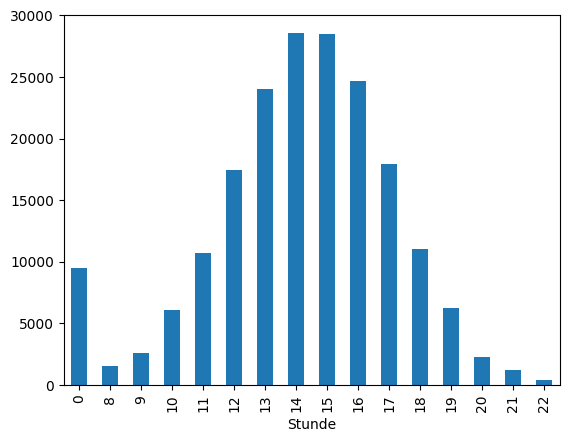

In [83]:
time = df.groupby('Stunde')['Systempicks'].sum()
time.plot(kind = 'bar')

In [25]:
df['Uhrzeit'].value_counts()

Uhrzeit
00:00:00    3782
14:45:19      23
16:42:14      22
15:18:00      21
14:35:18      21
            ... 
17:05:07       1
18:13:36       1
17:33:22       1
16:30:32       1
16:27:46       1
Name: count, Length: 18412, dtype: int64

In [26]:
df.groupby('Tag')['Systempicks'].sum().mean()

np.float64(13763.714285714286)

In [27]:
df[df['direktlagerung'] == True].groupby('Tag')['Systempicks'].sum().mean()

np.float64(10639.142857142857)

Ein großer Teil der Systempicks tritt um genau 00:00 auf. Vermutlich handelt es sich dabei um aggregierte Zahlen für die Zeiten zwischen 23:00 und 8:00. Da es bei Aufgabe 4.2 um die Ermittlung von typischen Lastenverläufen und Lastenspitzen geht, werde ich Systempicks, die um 00:00 auftreten nicht abbilden. Diese Bestellungen werden jedoch bei der Berechnugn der Systemleistung wieder miteinbezogen.

In [85]:
#Kopieren der Daten für Änderungen
df4_2 = df[df['Stunde'] != 0].copy()

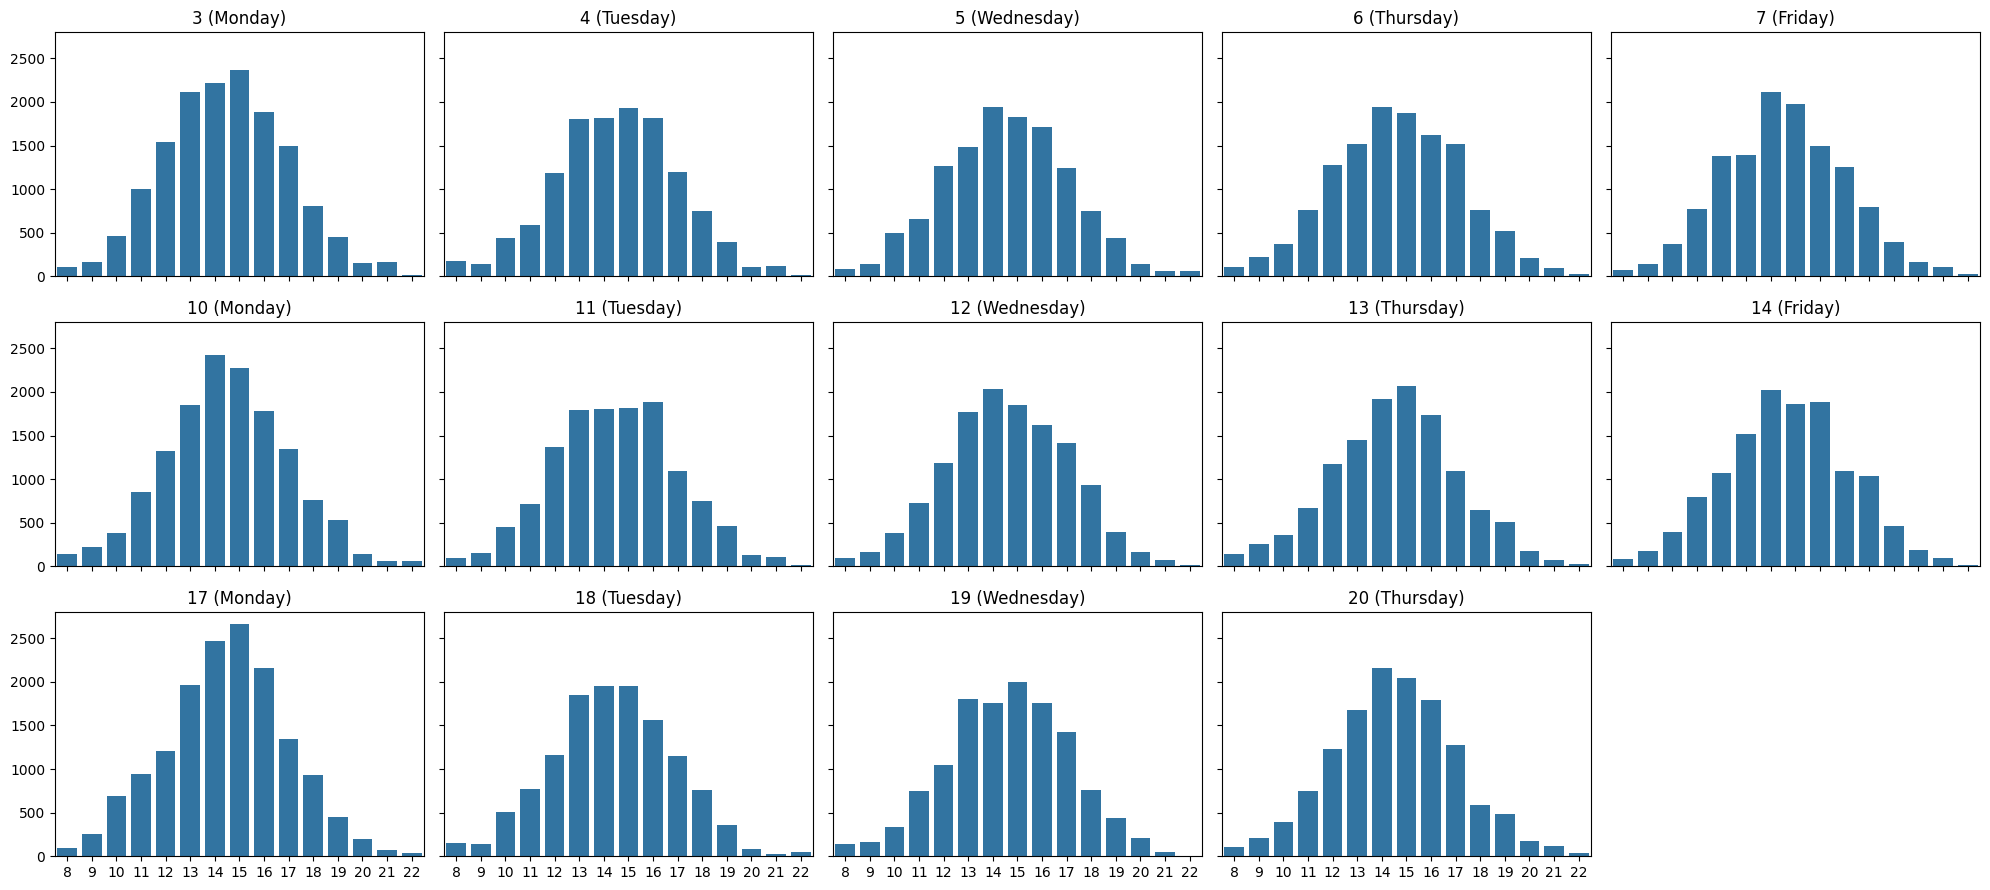

In [84]:
#Tagesverlauf pro Tag zeigt Auffälligkeiten
days = sorted(df4_2['Tag'].unique())
n = len(days)
cols = 5
rows = math.ceil(n/ cols)


fig, axes = plt.subplots(rows, cols, figsize = (cols * 4, rows * 3), sharex = True, sharey = True,)
axes= axes.flatten()

for i, day in enumerate(days):
    d = df4_2[df4_2['Tag'] == day]

    # 2) Summe Systempicks pro Stunde
    hourly = (d.groupby('Stunde', as_index=False)['Systempicks']
                .sum()
                .sort_values('Stunde'))

    # 3) Plot
    sns.barplot(data=hourly, x='Stunde', y='Systempicks', ax=axes[i], errorbar=None)
    axes[i].set_title(str(day))
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    weekday = d['timestamp'].iloc[0].day_name()
    axes[i].set_title(f"{day} ({weekday})")

for j in range(i+1, len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

- Stabilität über Tage
- Jeweils Peak um 14-15 Uhr.
- Davor Klarer Anstieg und danach Klarer Abfall
- Immer ein Peak -> gut planbar
- außerhalb 10-18 Uhr kaum Systemlast
- höheres Volumen am Montag deutet auf einen möglichen Nachholeffekt aus dem Wochenende hin
- restliche Tage ca. gleiches Volumen

<Axes: xlabel='Stunde', ylabel='Systempicks'>

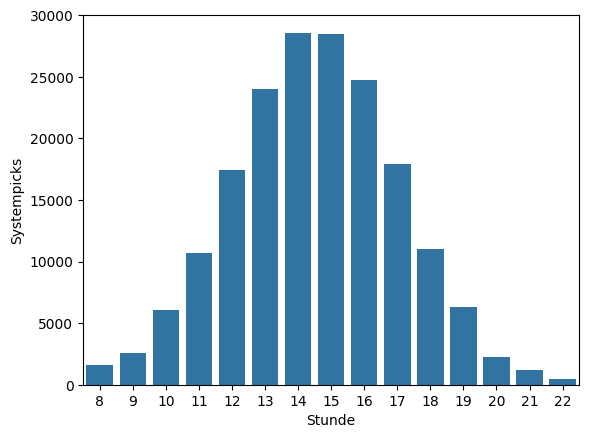

In [86]:
#aggregierte Systemlast im Tagesverlauf
hourly = df4_2.groupby('Stunde')['Systempicks'].sum()
sns.barplot(hourly)

In [32]:
#Werte für Präsentation Kommentar entfernen
# hourly

<Axes: xlabel='Wochentag', ylabel='Systempicks'>

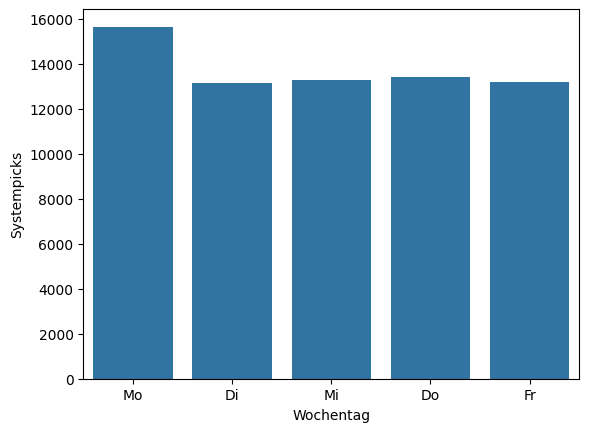

In [88]:
#Durchschnittliche Systemlast pro Wochentag mit 00:00 Einträgen
daily = df.groupby(['Datum', 'Wochentag'], as_index = False, observed = True)['Systempicks'].sum()
weekday_avg = daily.groupby('Wochentag', as_index = False, observed = True)['Systempicks'].mean()
sns.barplot(data = weekday_avg, x = 'Wochentag', y = 'Systempicks')

In [89]:
#Werte für Präsentation Kommentar entfernen
weekday_avg

,Wochentag,Systempicks
0,Mo,15635.000000
1,Di,13151.000000
2,Mi,13273.666667
3,Do,13385.666667
4,Fr,13178.000000


### Getrennte Auswertung nach Lagerart

Text(0.5, 1.0, 'Direktlagerung')

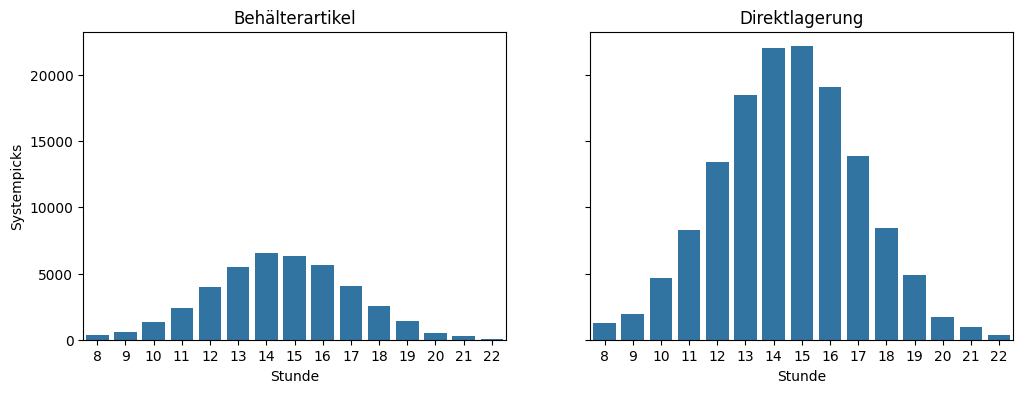

In [34]:
#Durchschnittlich stündliche Lastverteilung Behälterartikel vs Direktlagerartikel
beh = df4_2[df4_2['behälterlagerung'] == True].groupby('Stunde')['Systempicks'].sum()
dir = df4_2[df4_2['direktlagerung'] == True].groupby('Stunde')['Systempicks'].sum()

fig, axes = plt.subplots(1, 2, figsize = (12, 4), sharex = True, sharey = True)
sns.barplot(beh, ax = axes[0])
sns.barplot(dir, ax = axes[1])
axes[0].set_title('Behälterartikel')
axes[1].set_title('Direktlagerung')

In [ ]:
#beh

In [ ]:
#dir

Die stündliche Verteilung der Systempicks zeigt für Direkt- und Behälterartikel ein sehr ähnliches Lastprofil mit sehr ähnlichen Peak-Zeiten zwischen ca. 12 und 16 Uhr.
Es ergeben sich keine strukturellen Unterschiede, die eine getrennte zeitliche Auslegung der Systemleistung erforderlich machen.

Text(0.5, 1.0, 'Direktlagerung')

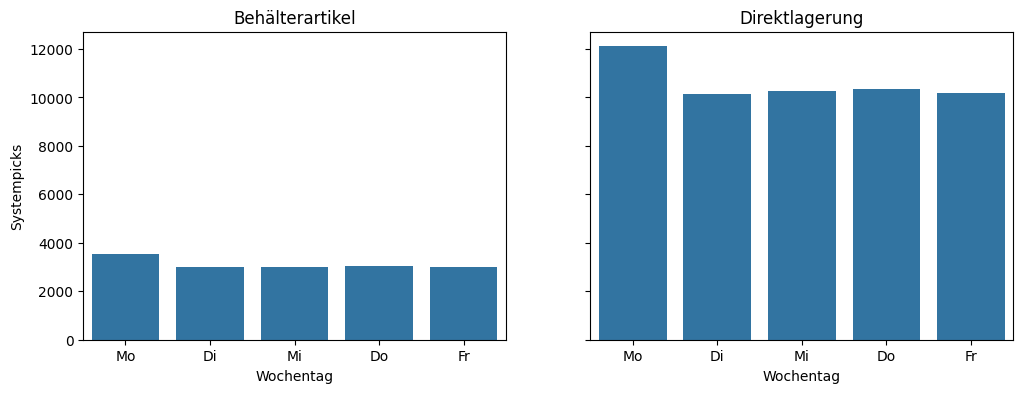

In [91]:
#Durchschnittliche Lastverteilung pro Wochentag Behälterartikel vs Direktlagerartikel
beh = df[df['behälterlagerung'] == True].groupby(['Tag', 'Wochentag'], as_index = False, observed = True)['Systempicks'].sum()
beh_avg = beh.groupby('Wochentag', observed = True)['Systempicks'].mean()

dir = df[df['direktlagerung'] == True].groupby(['Tag', 'Wochentag'],as_index = False, observed = True)['Systempicks'].sum()
dir_avg = dir.groupby('Wochentag', observed = True)['Systempicks'].mean()

fig, axes = plt.subplots(1, 2, figsize = (12, 4), sharex = True, sharey = True)
sns.barplot(beh_avg, ax = axes[0])
sns.barplot(dir_avg, ax = axes[1])
axes[0].set_title('Behälterartikel')
axes[1].set_title('Direktlagerung')

In [ ]:
#beh_avg

In [ ]:
#beh_avg / 3358.33333

In [ ]:
dir_avg / 11504.66666666666

Sowohl für Direkt- als auch für Behälterartikel zeigt sich ein ausgeprägter Montagseffekt mit einer im Mittel deutlich höheren Tageslast gegenüber den übrigen Wochentagen.
Das relative Wochenprofil ist für beide Lagerarten sehr ähnlich, sodass sich die erhöhte Systemlast am Montag unabhängig von der Lagerart ergibt.

In [36]:
#Berechnung Anteil zwischen 14:00 und 15:59
peak_share = 100 * (
    df4_2.loc[df4_2['Stunde'].isin([14, 15]), 'Systempicks'].sum()
    / df4_2['Systempicks'].sum()
)

#Berechnung der Zusatzlast am Montag
daily = df4_2.groupby(['Tag', 'Wochentag'], observed=True)['Systempicks'].sum().reset_index()

mo_mean = daily.loc[daily['Wochentag'] == 'Mo', 'Systempicks'].mean()
other_mean = daily.loc[daily['Wochentag'] != 'Mo', 'Systempicks'].mean()

mo_vs_others = 100 * (mo_mean / other_mean - 1)

#print der Kennzahlen
print('Anteil Systempicks zwischen 14:00 und 15:59 Uhr:', 
      round(peak_share, 1), 
     '%')
print('Druchschnittliche Extralast am Montag:', 
      round(mo_vs_others, 1), 
     '%')


Anteil Systempicks zwischen 14:00 und 15:59 Uhr: 31.2 %
Druchschnittliche Extralast am Montag: 17.9 %


## 4.3 Ableitung der empfohlenen Systemleistung

Die Systemempfehlungen werden ohne Einbezug der MISS-Artikel erhoben. Diese stellen knapp 2% der verkauften Artikel.

In [37]:
#Kopie für Änderungen, '00:00'- Einträge wieder vorhanden
df4_3 = df[['Systempicks', 'Tag', 'Wochentag']].copy()

In [38]:
#Gruppieren der aggregierten Systempicks pro Tag
daily_load = df4_3.groupby('Tag')['Systempicks'].sum()
pd.DataFrame(daily_load.describe())

,Systempicks
count,14.000000
mean,13763.714286
std,1073.462867
min,12952.000000
25%,13112.250000
50%,13293.000000
75%,13659.500000
max,16279.000000


In [39]:
daily_load.quantile(0.75)

np.float64(13659.5)

In [40]:
# Systemleistung für 75%-Quantil auf 16 Stunden
load_16 = math.ceil(daily_load.quantile(0.75) / 16)
print('Benötigte Systemleistung Q75 auf 16 Stunden:', load_16)

# Systemleistung für Maximaltag auf 24 Stunden
load_24 = math.ceil(daily_load.max() / 24)
print('Benötigte Systemleistung Maximaltag auf 24 Stunden:', load_24)

leistung_empf = np.maximum(load_16, load_24)

Benötigte Systemleistung Q75 auf 16 Stunden: 854
Benötigte Systemleistung Maximaltag auf 24 Stunden: 679


In [41]:
leistung_empf = np.maximum(load_16, load_24)
print('Empfehlung Systemleistung:', leistung_empf, 'Systempicks/h' )

Empfehlung Systemleistung: 854 Systempicks/h


Da die aus dem Q75 abgeleitete Stundenleistung höher ist als die für den Maximaltag erforderliche Leistung, wird die Systemauslegung auf 854 Systempicks pro Stunde empfohlen.
Mit einer Systemleistung von 854 Systempicks/h können 75 % der Tage innerhalb von 16 Betriebsstunden abgewickelt werden; der maximale Tag wird innerhalb von 24 Stunden bewältigt

## 4.4 Auslegung der Outbound-Stationen (OB-Stationen)
#### - Paket- und Palettenanteil der Bestellungen
#### - Empfehlungen der OB-Stationsanzahl

Analog zu 4.2 und 4.3 werden MISS- Artikel nicht in die Rechnung miteinbezogen

In [45]:
#Kopieren für Änderungen
df4_4 = df[['Order-ID','Artikelnummer', 'Systempicks', 'Tag', 'Anzahl', 'Länge', 'Breite', 'Höhe']].copy()

### Paket- und Palettenanteil der Bestellungen

In [47]:
#Erzeugen von Volumen-Feature pro Bestellposition
df4_4['Position_Volumen'] = df4_4['Anzahl'] * (df4_4['Länge'] / 1000) * (df4_4['Breite'] / 1000) * (df4_4['Höhe'] / 1000)

In [48]:
#Gruppieren der Bestellpositionen nach Order-ID
df_orders = df4_4.groupby('Order-ID', as_index = False).agg(
    Order_Volumen = ('Position_Volumen', 'sum'),
    Positionen = ('Artikelnummer', 'count'),
    Einheiten = ('Anzahl', 'sum'),
    Systempicks = ('Systempicks', 'sum'),
    Tag = ('Tag', 'first')
)

In [61]:
#Erstellen von Paket-Feature für Bestellungen für Paket-OB-Stationen
df_orders['Paket'] = df_orders['Order_Volumen'] <= 0.432

#Wie viele Bestellungen?
print('Anzahl Besetllungen;',df_orders.shape[0])
print('Anzahl Bestellungen Paket:', df_orders[df_orders['Paket'] == True].shape[0])

Anzahl Besetllungen; 28003
Anzahl Bestellungen Paket: 19005


Text(0.5, 1.0, 'Anteil Paket / Palette')

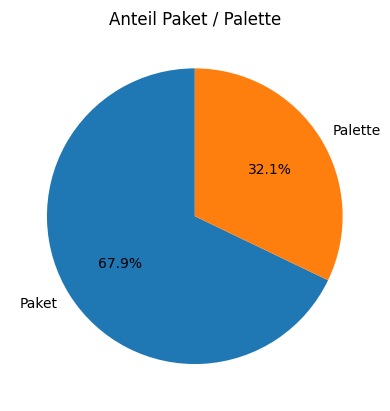

In [52]:
#Visualisieren Paket- und Palettenanteil der Bestellungen
labels = ['Paket', 'Palette']
values = [df_orders['Paket'].sum(), 
          df_orders.shape[0] - df_orders['Paket'].sum()]
plt.pie(values, labels = labels, autopct = '%1.1f%%', startangle = 90)
plt.title('Anteil Paket / Palette')

### Empfehlungen der OB-Stationsanzahl
Die Empfehlung der OB-Stationsanzahl wird analog zu Herangehensweise in 4.3 erfolgen, basierend auf den 75%-Quantilen in 16 Stunden, sowie den Maximaltagen in 24 Stunden. Dies erfolgt bei **Paket-Bestellungen** und **Paletten-Bestellungen** jeweils für Positionenzahl, Artikelzahl und Systempickzahl. Ausschlaggebend für die Empfehlung ist jeweils der Engpass, also die jenige Metrik, die die meisten OB-Stationen benötigt, um die Last zu bewältigen aufgerundet auf die nächste ganze Zahl.

In [53]:
#Unterteilen der Bestellungsdaten in Paket- und Palettenbestellungen
df_paket = df_orders[df_orders['Paket'] == True]
df_palette = df_orders[df_orders['Paket'] == False]

#### Empfehlung Paket-OB-Stationen

In [55]:
#Berechnung der Empfehlung für Paket-OB-Stationen
q75_bes = df_paket.groupby('Tag')['Order-ID'].count().quantile(0.75) / 16 / 140
q75_eh = df_paket.groupby('Tag')['Einheiten'].sum().quantile(0.75) / 16 / 300
q75_sp = df_paket.groupby('Tag')['Systempicks'].sum().quantile(0.75) / 16 / 200

max_bes = df_paket.groupby('Tag')['Order-ID'].count().max() / 24 / 140
max_eh = df_paket.groupby('Tag')['Einheiten'].sum().max() / 24 / 300
max_sp = df_paket.groupby('Tag')['Systempicks'].sum().max() / 24 / 200

anzahl = math.ceil(max([q75_bes, q75_eh, q75_sp, max_bes, max_eh, max_sp]))
print('Empfohlene Anzahl:', anzahl)

Empfohlene Anzahl: 3


In [56]:
#Bottleneckanzeigen
bottleneck = {
    'Q75 Bestellungen': q75_bes,
    'Q75 Einheiten': q75_eh,
    'Q75 Systempicks': q75_sp,
    'Max Bestellungen': max_bes,
    'Max Einheiten': max_eh,
    'Max Systempicks': max_sp
}

pd.Series(bottleneck).sort_values(ascending=False)

Q75 Einheiten       2.631250
Max Einheiten       2.062500
Q75 Systempicks     1.922344
Max Systempicks     1.495208
Q75 Bestellungen    0.604241
Max Bestellungen    0.469940
dtype: float64

#### Empfehlung Paletten-OB-Stationen

In [57]:
#Berechnung der Empfehlung für Paletten-OB-Stationen
q75_bes = df_palette.groupby('Tag')['Order-ID'].count().quantile(0.75) / 16 / 20
q75_eh = df_palette.groupby('Tag')['Einheiten'].sum().quantile(0.75) / 16 / 500
q75_sp = df_palette.groupby('Tag')['Systempicks'].sum().quantile(0.75) / 16 / 400

max_bes = df_palette.groupby('Tag')['Order-ID'].count().max() / 24 / 20
max_eh = df_palette.groupby('Tag')['Einheiten'].sum().max() / 24 / 500
max_sp = df_palette.groupby('Tag')['Systempicks'].sum().max() / 24 / 400

anzahl = math.ceil(max([q75_bes, q75_eh, q75_sp, max_bes, max_eh, max_sp]))
print('Empfohlene Anzahl:', anzahl)

Empfohlene Anzahl: 3


In [58]:
#Bottleneck anzeigen
bottleneck = {
    'Q75 Bestellungen': q75_bes,
    'Q75 Einheiten': q75_eh,
    'Q75 Systempicks': q75_sp,
    'Max Bestellungen': max_bes,
    'Max Einheiten': max_eh,
    'Max Systempicks': max_sp
}

pd.Series(bottleneck).sort_values(ascending=False)

Q75 Bestellungen    2.047656
Max Bestellungen    1.579167
Q75 Einheiten       1.506531
Q75 Systempicks     1.209492
Max Einheiten       1.187583
Max Systempicks     0.948125
dtype: float64